In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.6 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source 

In [9]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
my_roboflow_key = user_secrets.get_secret("ROBOFLOW_API_KEY")

# 3. Download your cloned dataset (using the safe variable)


In [14]:
from roboflow import Roboflow
rf = Roboflow(api_key=my_roboflow_key)
project = rf.workspace("menlo-college").project("petri-6bh2z")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to petri-1 in yolov8:: 100%|██████████| 19962/19962 [00:01<00:00, 10441.11it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
import os
print(os.listdir('/kaggle/working/'))

['.virtual_documents', 'petri-1']


In [16]:
import os
for root, dirs, files in os.walk('/kaggle/working/petri-1'):
    level = root.replace('/kaggle/working/petri-1', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:
            print(f'{subindent}{file}')

petri-1/
  README.roboflow.txt
  data.yaml
  README.dataset.txt
  valid/
    labels/
    images/
  test/
    labels/
    images/
  train/
    labels/
    images/


In [17]:
with open('/kaggle/working/petri-1/data.yaml', 'r') as f:
    print(f.read())

names:
- B-subtilis
- C-albicans
- Contamination
- Defect
- E-coli
- P-aeruginosa
- S-aureus
nc: 7
roboflow:
  license: CC BY 4.0
  project: petri-6bh2z
  url: https://universe.roboflow.com/menlo-college/petri-6bh2z/dataset/1
  version: 1
  workspace: menlo-college
test: ../test/images
train: ../train/images
val: ../valid/images



In [18]:
import os

train_images = len(os.listdir('/kaggle/working/petri-1/train/images'))
val_images = len(os.listdir('/kaggle/working/petri-1/valid/images'))
test_images = len(os.listdir('/kaggle/working/petri-1/test/images'))

print(f"Train: {train_images}")
print(f"Val: {val_images}")
print(f"Test: {test_images}")
print(f"Total: {train_images + val_images + test_images}")

Train: 6984
Val: 1994
Test: 997
Total: 9975


In [19]:
import os
from collections import Counter

label_dir = '/kaggle/working/petri-1/train/labels'
class_counts = Counter()

for label_file in os.listdir(label_dir):
    with open(os.path.join(label_dir, label_file), 'r') as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

classes = ['B-subtilis', 'C-albicans', 'Contamination', 'Defect', 'E-coli', 'P-aeruginosa', 'S-aureus']
print("Class distribution in training set:")
for class_id, name in enumerate(classes):
    print(f"  {name}: {class_counts[class_id]}")

Class distribution in training set:
  B-subtilis: 14392
  C-albicans: 21903
  Contamination: 274
  Defect: 77
  E-coli: 32959
  P-aeruginosa: 27929
  S-aureus: 32226


In [22]:
import os
import shutil
import random
from collections import defaultdict, Counter

# Paths
train_img_dir = '/kaggle/working/petri-1/train/images'
train_lbl_dir = '/kaggle/working/petri-1/train/labels'
out_img_dir = '/kaggle/working/petri-1/train_stratified/images'
out_lbl_dir = '/kaggle/working/petri-1/train_stratified/labels'

# Clear previous stratified folder
shutil.rmtree('/kaggle/working/petri-1/train_stratified', ignore_errors=True)
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_lbl_dir, exist_ok=True)

# Classes
classes = ['B-subtilis', 'C-albicans', 'Contamination', 'Defect', 'E-coli', 'P-aeruginosa', 'S-aureus']

# Keep these at full size — too rare to sample
protected_classes = {2, 3}  # Contamination, Defect

# Group images by dominant class
class_to_images = defaultdict(list)
for label_file in os.listdir(train_lbl_dir):
    label_path = os.path.join(train_lbl_dir, label_file)
    with open(label_path, 'r') as f:
        lines = f.readlines()
    if lines:
        classes_in_image = [int(l.split()[0]) for l in lines]
        dominant_class = Counter(classes_in_image).most_common(1)[0][0]
        class_to_images[dominant_class].append(label_file.replace('.txt', ''))

# Sample 50% from common classes, keep 100% for rare ones
random.seed(42)
selected = []
for class_id, images in class_to_images.items():
    if class_id in protected_classes:
        selected.extend(images)  # full size
        print(f"{classes[class_id]}: keeping all {len(images)} images")
    else:
        n = max(1, len(images) // 2)
        selected.extend(random.sample(images, n))
        print(f"{classes[class_id]}: sampled {n}/{len(images)} images")

# Copy selected images and labels
for name in selected:
    for ext in ['.jpg', '.jpeg', '.png']:
        src_img = os.path.join(train_img_dir, name + ext)
        if os.path.exists(src_img):
            shutil.copy(src_img, out_img_dir)
            break
    src_lbl = os.path.join(train_lbl_dir, name + '.txt')
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, out_lbl_dir)

print(f"\nTotal selected: {len(selected)} stratified training images")

C-albicans: sampled 430/860 images
P-aeruginosa: sampled 644/1288 images
S-aureus: sampled 514/1029 images
E-coli: sampled 611/1222 images
B-subtilis: sampled 179/358 images
Defect: keeping all 5 images
Contamination: keeping all 1 images

Total selected: 2384 stratified training images


In [23]:
for split in ['valid', 'test']:
    label_dir = f'/kaggle/working/petri-1/{split}/labels'
    class_counts = Counter()
    for label_file in os.listdir(label_dir):
        with open(os.path.join(label_dir, label_file), 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1
    print(f"\n{split} set:")
    for class_id, name in enumerate(classes):
        print(f"  {name}: {class_counts[class_id]}")


valid set:
  B-subtilis: 3943
  C-albicans: 6623
  Contamination: 116
  Defect: 12
  E-coli: 9667
  P-aeruginosa: 7658
  S-aureus: 10369

test set:
  B-subtilis: 2257
  C-albicans: 2997
  Contamination: 28
  Defect: 11
  E-coli: 5839
  P-aeruginosa: 4056
  S-aureus: 4297


In [24]:
label_dir = '/kaggle/working/petri-1/train_stratified/labels'
class_counts = Counter()
for label_file in os.listdir(label_dir):
    with open(os.path.join(label_dir, label_file), 'r') as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

print("Current stratified training distribution:")
for class_id, name in enumerate(classes):
    print(f"  {name}: {class_counts[class_id]}")

Current stratified training distribution:
  B-subtilis: 6731
  C-albicans: 10476
  Contamination: 154
  Defect: 47
  E-coli: 16154
  P-aeruginosa: 12895
  S-aureus: 17166


In [25]:
import os

label_dirs = [
    '/kaggle/working/petri-1/train_stratified/labels',
    '/kaggle/working/petri-1/valid/labels',
    '/kaggle/working/petri-1/test/labels'
]

# 0,1,4,5,6 → colony(0), 2 → contamination(1), 3 → defect(2)
remap = {0:0, 1:0, 2:1, 3:2, 4:0, 5:0, 6:0}

for label_dir in label_dirs:
    for label_file in os.listdir(label_dir):
        label_path = os.path.join(label_dir, label_file)
        with open(label_path, 'r') as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            parts[0] = str(remap[int(parts[0])])
            new_lines.append(' '.join(parts))
        with open(label_path, 'w') as f:
            f.write('\n'.join(new_lines))

print("Remapping complete — 3 classes")

Remapping complete — 3 classes


In [26]:
label_dir = '/kaggle/working/petri-1/train_stratified/labels'
class_counts = Counter()
for label_file in os.listdir(label_dir):
    with open(os.path.join(label_dir, label_file), 'r') as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

total = sum(class_counts.values())
print("Post-remap training distribution:")
for class_id, name in enumerate(['colony', 'contamination', 'defect']):
    count = class_counts[class_id]
    pct = (count/total)*100
    print(f"  {name}: {count} ({pct:.1f}%)")
print(f"\nTotal annotations: {total}")

Post-remap training distribution:
  colony: 63422 (99.7%)
  contamination: 154 (0.2%)
  defect: 47 (0.1%)

Total annotations: 63623


In [31]:
import os
import shutil
import random
from collections import Counter

# Work from ORIGINAL train labels (before any remapping)
orig_lbl_dir = '/kaggle/working/petri-1/train/labels'
orig_img_dir = '/kaggle/working/petri-1/train/images'
out_lbl_dir = '/kaggle/working/petri-1/train_final/labels'
out_img_dir = '/kaggle/working/petri-1/train_final/images'

shutil.rmtree('/kaggle/working/petri-1/train_final', ignore_errors=True)
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_lbl_dir, exist_ok=True)

# Original class IDs: 2=Contamination, 3=Defect
rare_images = []
colony_images = []

for label_file in os.listdir(orig_lbl_dir):
    label_path = os.path.join(orig_lbl_dir, label_file)
    with open(label_path, 'r') as f:
        lines = f.readlines()
    if lines:
        classes_in_image = [int(l.split()[0]) for l in lines]
        if 2 in classes_in_image or 3 in classes_in_image:
            rare_images.append(label_file.replace('.txt', ''))
        else:
            colony_images.append(label_file.replace('.txt', ''))

print(f"Images containing contamination/defect: {len(rare_images)}")
print(f"Pure colony images: {len(colony_images)}")

# Remap function: 0,1,4,5,6→colony(0), 2→contamination(1), 3→defect(2)
remap = {0:0, 1:0, 2:1, 3:2, 4:0, 5:0, 6:0}

def copy_and_remap(name, src_img_dir, src_lbl_dir, dst_img_dir, dst_lbl_dir, suffix=''):
    # Copy and remap label
    src_lbl = os.path.join(src_lbl_dir, name + '.txt')
    if not os.path.exists(src_lbl):
        return False
    with open(src_lbl, 'r') as f:
        lines = f.readlines()
    new_lines = []
    for line in lines:
        parts = line.strip().split()
        parts[0] = str(remap[int(parts[0])])
        new_lines.append(' '.join(parts))
    with open(os.path.join(dst_lbl_dir, name + suffix + '.txt'), 'w') as f:
        f.write('\n'.join(new_lines))
    # Copy image
    for ext in ['.jpg', '.jpeg', '.png']:
        src_img = os.path.join(src_img_dir, name + ext)
        if os.path.exists(src_img):
            shutil.copy(src_img, os.path.join(dst_img_dir, name + suffix + ext))
            return True
    return False

# Copy ALL rare images + oversample 3x
random.seed(42)
for name in rare_images:
    copy_and_remap(name, orig_img_dir, orig_lbl_dir, out_img_dir, out_lbl_dir)
    for i in range(2):  # 2 extra copies = 3x total
        copy_and_remap(name, orig_img_dir, orig_lbl_dir, out_img_dir, out_lbl_dir, suffix=f'_aug{i}')

# Cap colony at 2x rare count
colony_cap = min(len(rare_images) * 2, len(colony_images))
colony_sampled = random.sample(colony_images, colony_cap)
for name in colony_sampled:
    copy_and_remap(name, orig_img_dir, orig_lbl_dir, out_img_dir, out_lbl_dir)

print(f"\nRare images (3x oversampled): {len(rare_images) * 3}")
print(f"Colony images: {len(colony_sampled)}")
print(f"Total: {len(os.listdir(out_img_dir))}")

Images containing contamination/defect: 204
Pure colony images: 4559

Rare images (3x oversampled): 612
Colony images: 408
Total: 1020


In [32]:
label_dir = '/kaggle/working/petri-1/train_final/labels'
class_counts = Counter()
for label_file in os.listdir(label_dir):
    with open(os.path.join(label_dir, label_file), 'r') as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

total = sum(class_counts.values())
print("Final training distribution:")
for class_id, name in enumerate(['colony', 'contamination', 'defect']):
    count = class_counts[class_id]
    pct = (count/total)*100
    print(f"  {name}: {count} ({pct:.1f}%)")
print(f"\nTotal annotations: {total}")

Final training distribution:
  colony: 27119 (96.3%)
  contamination: 822 (2.9%)
  defect: 231 (0.8%)

Total annotations: 28172


In [33]:
import yaml

yaml_path = '/kaggle/working/petri-1/data.yaml'
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['names'] = ['colony', 'contamination', 'defect']
data['nc'] = 3
data['train'] = '/kaggle/working/petri-1/train_final/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("data.yaml updated")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml updated
names:
- colony
- contamination
- defect
nc: 3
roboflow:
  license: CC BY 4.0
  project: petri-6bh2z
  url: https://universe.roboflow.com/menlo-college/petri-6bh2z/dataset/1
  version: 1
  workspace: menlo-college
test: ../test/images
train: /kaggle/working/petri-1/train_final/images
val: ../valid/images



In [37]:
!pip install "pillow==10.4.0"
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 44.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pillow
    Found existing installation: pillow 12.2.0
    Uninstalling pillow-12.2.0:
      Successfully uninstalled pillow-12.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pi-heif 1.3.0 requires pillow>=11.1.0, but you have pillow 10.4.0 which is incompatible.
inference-sdk 1.2.10 requires pillow<13.0.0,>=12.2.0, but you have pillow 10.4.0 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [1]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

results = model.train(
    data='/kaggle/working/petri-1/data.yaml',
    epochs=25,
    patience=10,
    imgsz=640,
    device=0,
    cache=True,
    project='/kaggle/working/',
    name='lablens_colony_detector'
)

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/petri-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lablens_colony_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [3]:
from IPython.display import FileLink

# Generate a clickable link to your trained weights
FileLink(r'lablens_colony_detector-2/weights/best.pt')

/kaggle/working/lablens_colony_detector-2/weights/best.pt

Images with contamination: 480
Images with defect: 150


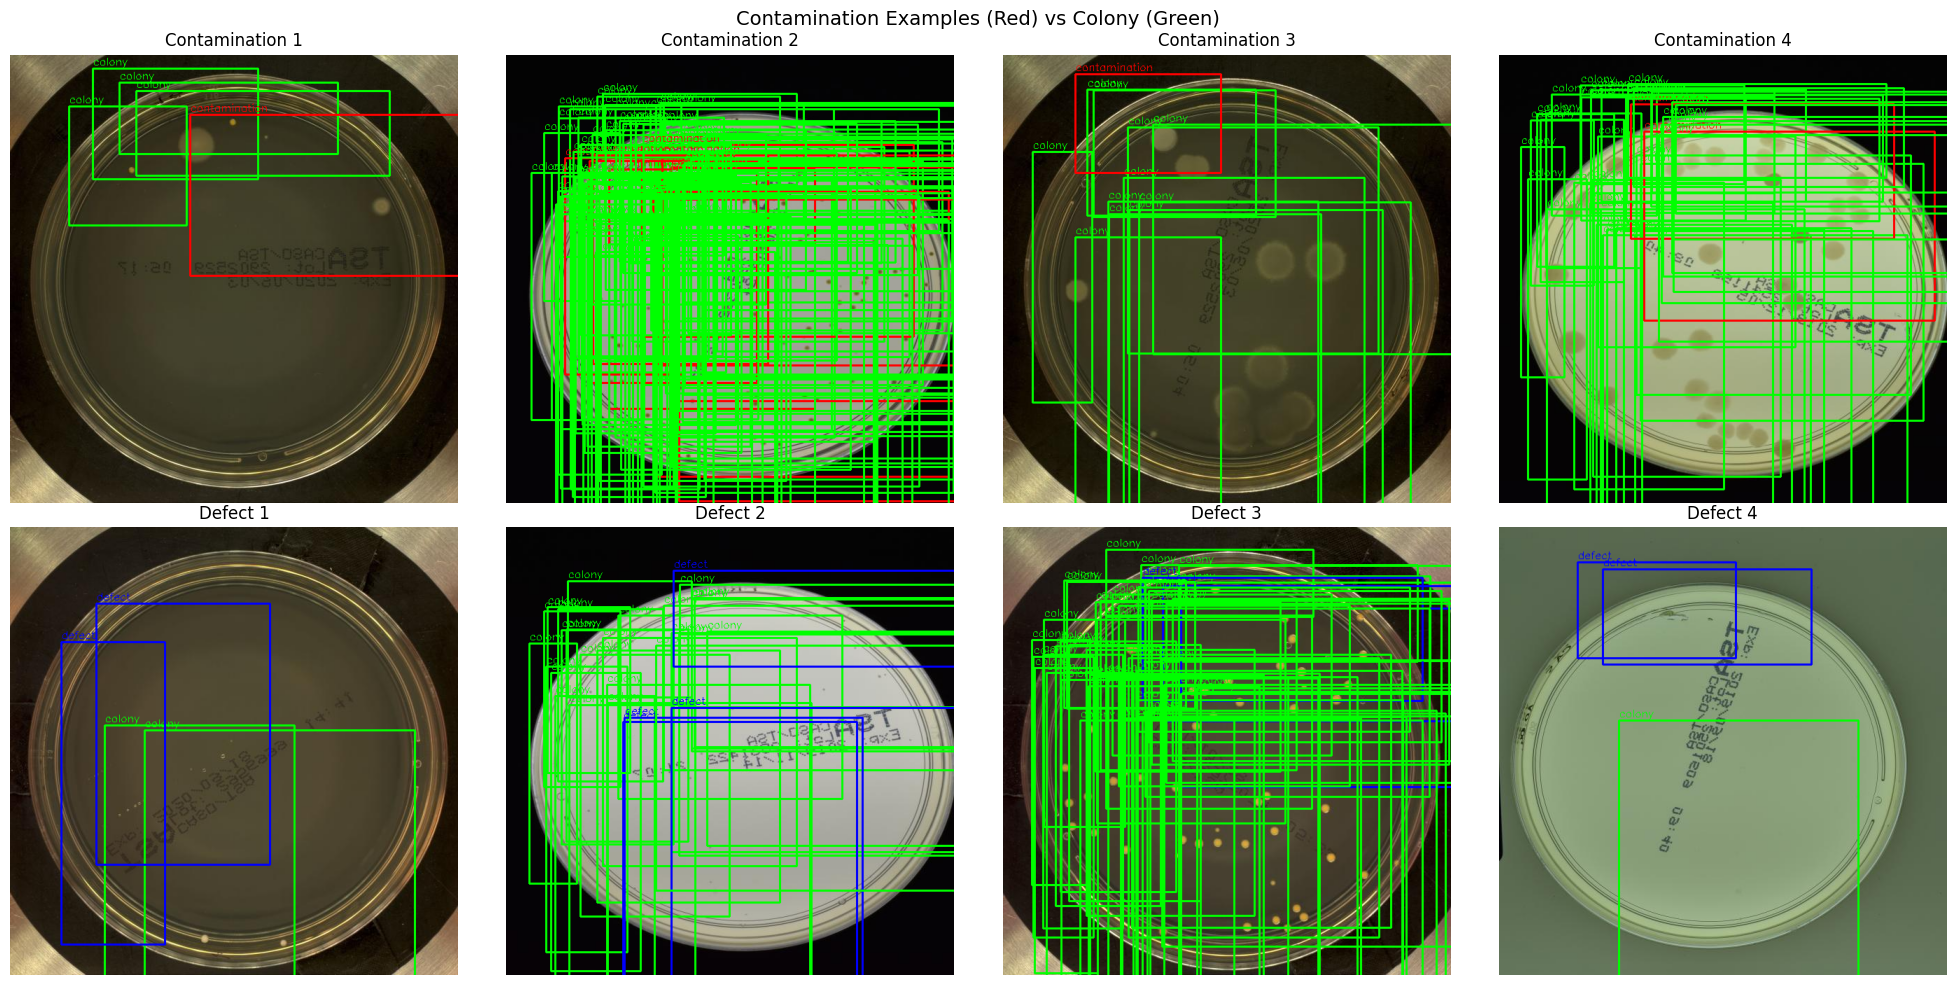

Saved to /kaggle/working/rare_class_examples.png


In [4]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

img_dir = '/kaggle/working/petri-1/train_final/images'
lbl_dir = '/kaggle/working/petri-1/train_final/labels'
classes = ['colony', 'contamination', 'defect']
colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255)]  # green, red, blue

def draw_boxes(img_path, lbl_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    with open(lbl_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        cls = int(parts[0])
        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), colors[cls], 2)
        cv2.putText(img, classes[cls], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[cls], 1)
    return img

# Find images containing contamination (1) or defect (2)
contamination_imgs = []
defect_imgs = []

for lbl_file in os.listdir(lbl_dir):
    lbl_path = os.path.join(lbl_dir, lbl_file)
    with open(lbl_path, 'r') as f:
        lines = f.readlines()
    classes_in_img = [int(l.split()[0]) for l in lines]
    img_name = lbl_file.replace('.txt', '')
    # Find matching image
    for ext in ['.jpg', '.jpeg', '.png']:
        img_path = os.path.join(img_dir, img_name + ext)
        if os.path.exists(img_path):
            if 1 in classes_in_img:
                contamination_imgs.append((img_path, lbl_path))
            if 2 in classes_in_img:
                defect_imgs.append((img_path, lbl_path))
            break

print(f"Images with contamination: {len(contamination_imgs)}")
print(f"Images with defect: {len(defect_imgs)}")

# Plot 4 contamination examples
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Contamination Examples (Red) vs Colony (Green)', fontsize=14)

for i in range(min(4, len(contamination_imgs))):
    img = draw_boxes(*contamination_imgs[i])
    axs[0, i].imshow(img)
    axs[0, i].set_title(f'Contamination {i+1}')
    axs[0, i].axis('off')

# Plot 4 defect examples
for i in range(min(4, len(defect_imgs))):
    img = draw_boxes(*defect_imgs[i])
    axs[1, i].imshow(img)
    axs[1, i].set_title(f'Defect {i+1}')
    axs[1, i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/rare_class_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /kaggle/working/rare_class_examples.png")